In [1]:
#1. Implement K-nearest neighbor classifier and provide the accuracy

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

# Normalize and split the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# K-nearest neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # Using 5 neighbors for KNN
knn.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy: {accuracy}')

accuracy: 0.975


In [4]:
#2. Implement any DL-based image classification algorithm except AlexNet and provide the accuracy
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Load and preprocess data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(lr=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, batch_size=64, epochs=20, validation_split=0.1, verbose=2)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print('Test accuracy:', test_acc)

SymbolAlreadyExposedError: Symbol Zeros is already exposed as ().

Using cache found in C:\Users\baraa/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2024-4-21 Python-3.8.17 torch-2.1.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
image 1/1: 540x960 1 person, 1 car, 1 cat, 1 dog, 1 pizza
Speed: 8.0ms pre-process, 94.0ms inference, 1.0ms NMS per image at shape (1, 3, 384, 640)


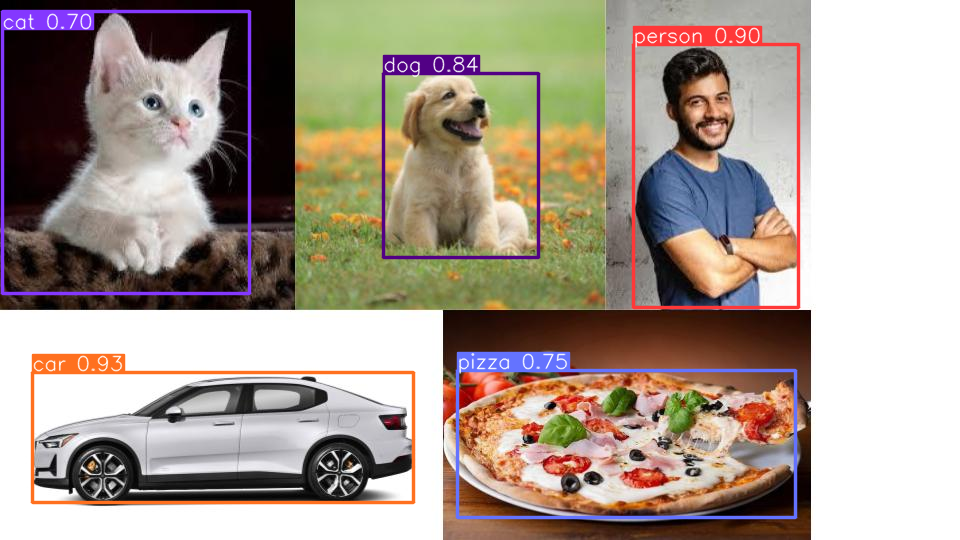

Class: car, Box: [32.751949310302734, 372.4914855957031, 413.8520812988281, 502.7715759277344], Confidence: 0.932765781879425
Class: person, Box: [633.8941040039062, 44.799591064453125, 798.4409790039062, 307.5051574707031], Confidence: 0.8970134258270264
Class: dog, Box: [383.57354736328125, 73.50759887695312, 538.1078491210938, 257.7984924316406], Confidence: 0.837752640247345
Class: pizza, Box: [457.6960144042969, 370.7787170410156, 795.496826171875, 517.5028686523438], Confidence: 0.7530773878097534
Class: cat, Box: [2.1044654846191406, 11.60244369506836, 249.93722534179688, 293.1636962890625], Confidence: 0.6964542865753174


In [6]:
#3. Implement any DL-based object detection (R-CNN, YOLO etc.) pipeline. You do not need to
# train the network. Run the inference using pretrained object detection models. Provide the 
# object detection results for 5 different classes/objects.

# Installations and Initialization

# pip install torch torchvision
# git clone https://github.com/ultralytics/yolov5
# cd yolov5
# pip install -r requirements.txt

# Load the model from Ultralytics' YOLOv5 model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

import torch

from PIL import Image

image_path = '5images.jpg'
img = Image.open(image_path)

# Use YOLOv5's utilities for processing
imgs = [img]  # batch of images
results = model(imgs)

# Print results
results.print()

# Plot results with bounding boxes and labels
results.show()

# Extract bounding boxes and labels
detected_objects = results.xyxy[0]  # Tensor of shape [n, 6], with (x1, y1, x2, y2, confidence, class)
for x in detected_objects:
    print(f'Class: {model.names[int(x[5])]}, Box: {x[:4].tolist()}, Confidence: {x[4].item()}')